# Wczytanie bibliotek i bazy danych

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime as dt

from wordcloud import WordCloud, STOPWORDS
import re, string, unicodedata

import nltk
from nltk import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import LancasterStemmer, WordNetLemmatizer
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
nltk.download('stopwords')
import string
string.punctuation
nltk.download('omw-1.4')
from nltk.tokenize import TweetTokenizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.feature_extraction import text
from sklearn.decomposition import TruncatedSVD

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

%matplotlib inline
sns.set()

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [ ]:
original_df = pd.read_csv('movies.csv',index_col='index')
df = original_df.copy()

In [ ]:
df.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,cast,crew,director
index,,,,,,,,,,,,,,,,,,,,,
0,237000000,Action Adventure Fantasy Science Fiction,http://www.avatarmovie.com/,19995,culture clash future space war space colony so...,en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,Sam Worthington Zoe Saldana Sigourney Weaver S...,"[{'name': 'Stephen E. Rivkin', 'gender': 0, 'd...",James Cameron
1,300000000,Adventure Fantasy Action,http://disney.go.com/disneypictures/pirates/,285,ocean drug abuse exotic island east india trad...,en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,Johnny Depp Orlando Bloom Keira Knightley Stel...,"[{'name': 'Dariusz Wolski', 'gender': 2, 'depa...",Gore Verbinski
2,245000000,Action Adventure Crime,http://www.sonypictures.com/movies/spectre/,206647,spy based on novel secret agent sequel mi6,en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,Daniel Craig Christoph Waltz L\u00e9a Seydoux ...,"[{'name': 'Thomas Newman', 'gender': 2, 'depar...",Sam Mendes
3,250000000,Action Crime Drama Thriller,http://www.thedarkknightrises.com/,49026,dc comics crime fighter terrorist secret ident...,en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",...,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,Christian Bale Michael Caine Gary Oldman Anne ...,"[{'name': 'Hans Zimmer', 'gender': 2, 'departm...",Christopher Nolan
4,260000000,Action Adventure Science Fiction,http://movies.disney.com/john-carter,49529,based on novel mars medallion space travel pri...,en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",...,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,Taylor Kitsch Lynn Collins Samantha Morton Wil...,"[{'name': 'Andrew Stanton', 'gender': 2, 'depa...",Andrew Stanton


# Przygotowanie danych

In [ ]:
df.columns

Index(['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'vote_average',
       'vote_count', 'cast', 'crew', 'director'],
      dtype='object')

In [ ]:
df = df[['title', 'genres', 'keywords', 'original_language', 'original_title',
         'overview', 'production_countries', 'cast', 'director']]
df.head()

,title,genres,keywords,original_language,original_title,overview,production_countries,cast,director
index,,,,,,,,,
0,Avatar,Action Adventure Fantasy Science Fiction,culture clash future space war space colony so...,en,Avatar,"In the 22nd century, a paraplegic Marine is di...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",Sam Worthington Zoe Saldana Sigourney Weaver S...,James Cameron
1,Pirates of the Caribbean: At World's End,Adventure Fantasy Action,ocean drug abuse exotic island east india trad...,en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",Johnny Depp Orlando Bloom Keira Knightley Stel...,Gore Verbinski
2,Spectre,Action Adventure Crime,spy based on novel secret agent sequel mi6,en,Spectre,A cryptic message from Bond’s past sends him o...,"[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",Daniel Craig Christoph Waltz L\u00e9a Seydoux ...,Sam Mendes
3,The Dark Knight Rises,Action Crime Drama Thriller,dc comics crime fighter terrorist secret ident...,en,The Dark Knight Rises,Following the death of District Attorney Harve...,"[{""iso_3166_1"": ""US"", ""name"": ""United States o...",Christian Bale Michael Caine Gary Oldman Anne ...,Christopher Nolan
4,John Carter,Action Adventure Science Fiction,based on novel mars medallion space travel pri...,en,John Carter,"John Carter is a war-weary, former military ca...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",Taylor Kitsch Lynn Collins Samantha Morton Wil...,Andrew Stanton


In [ ]:
df.shape

(4803, 9)

In [ ]:
df.duplicated().value_counts()

,count
False,4803


<Axes: ylabel='index'>

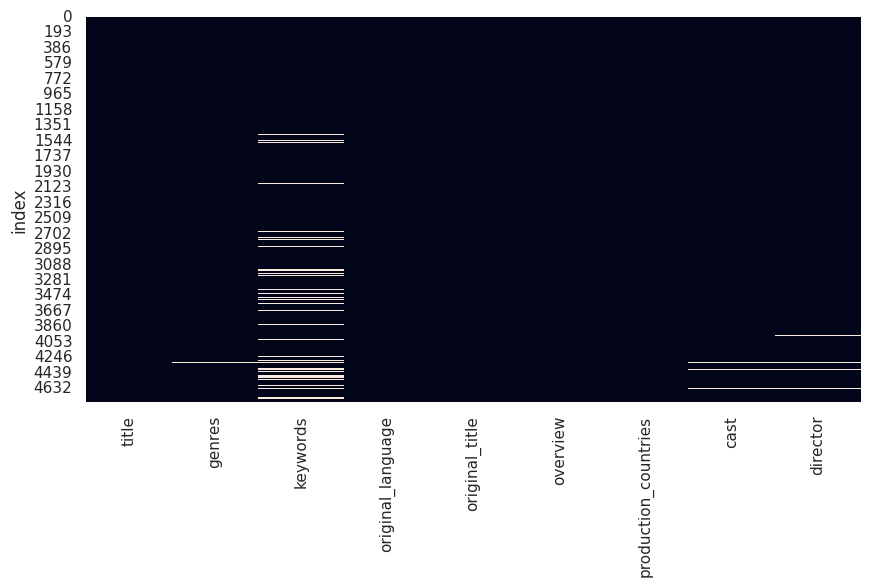

In [ ]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False)

In [ ]:
df.isna().sum()

,0
title,0
genres,28
keywords,412
original_language,0
original_title,0
overview,3
production_countries,0
cast,43
director,30


* Brakujące wartości w `director`, `genres` i `cast` uzupełniamy jako `Unknown`.
* Brakujące wartości w `keywords` i `overview` zostawiamy "puste".

In [ ]:
df[['director','genres','cast']] = df[['director','genres', 'cast']].fillna('Unknown')
df[['keywords', 'overview']] = df[['keywords', 'overview']].fillna('')

In [ ]:
import ast

def extract_names(val):
    if pd.isna(val) or val == "":
        return None

    try:
        data = ast.literal_eval(val)

        if isinstance(data, list):
            return ", ".join([i['name'] for i in data if 'name' in i])

        if isinstance(data, dict):
            return data.get('name')

    except (ValueError, SyntaxError):
        return val

df['production_countries'] = df['production_countries'].apply(extract_names)
df.head()

,title,genres,keywords,original_language,original_title,overview,production_countries,cast,director
index,,,,,,,,,
0,Avatar,Action Adventure Fantasy Science Fiction,culture clash future space war space colony so...,en,Avatar,"In the 22nd century, a paraplegic Marine is di...","United States of America, United Kingdom",Sam Worthington Zoe Saldana Sigourney Weaver S...,James Cameron
1,Pirates of the Caribbean: At World's End,Adventure Fantasy Action,ocean drug abuse exotic island east india trad...,en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",United States of America,Johnny Depp Orlando Bloom Keira Knightley Stel...,Gore Verbinski
2,Spectre,Action Adventure Crime,spy based on novel secret agent sequel mi6,en,Spectre,A cryptic message from Bond’s past sends him o...,"United Kingdom, United States of America",Daniel Craig Christoph Waltz L\u00e9a Seydoux ...,Sam Mendes
3,The Dark Knight Rises,Action Crime Drama Thriller,dc comics crime fighter terrorist secret ident...,en,The Dark Knight Rises,Following the death of District Attorney Harve...,United States of America,Christian Bale Michael Caine Gary Oldman Anne ...,Christopher Nolan
4,John Carter,Action Adventure Science Fiction,based on novel mars medallion space travel pri...,en,John Carter,"John Carter is a war-weary, former military ca...",United States of America,Taylor Kitsch Lynn Collins Samantha Morton Wil...,Andrew Stanton


In [ ]:
df.production_countries.value_counts()

,count
production_countries,
United States of America,2977
"United Kingdom, United States of America",181
,174
United Kingdom,131
"Germany, United States of America",119
...,...
"United Kingdom, South Africa",1
"United States of America, France, Mexico",1
"Mexico, Spain",1


Dla uproszczenia analizy, jako kraj produkcji zostawiamy tylko pierwszy z wymienionych.

In [ ]:
df['production_countries'] = df['production_countries'].apply(lambda x: x.split(',')[0])

In [ ]:
df = df.rename(columns={'production_countries': 'country'})
df.head()

,title,genres,keywords,original_language,original_title,overview,country,cast,director
index,,,,,,,,,
0,Avatar,Action Adventure Fantasy Science Fiction,culture clash future space war space colony so...,en,Avatar,"In the 22nd century, a paraplegic Marine is di...",United States of America,Sam Worthington Zoe Saldana Sigourney Weaver S...,James Cameron
1,Pirates of the Caribbean: At World's End,Adventure Fantasy Action,ocean drug abuse exotic island east india trad...,en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",United States of America,Johnny Depp Orlando Bloom Keira Knightley Stel...,Gore Verbinski
2,Spectre,Action Adventure Crime,spy based on novel secret agent sequel mi6,en,Spectre,A cryptic message from Bond’s past sends him o...,United Kingdom,Daniel Craig Christoph Waltz L\u00e9a Seydoux ...,Sam Mendes
3,The Dark Knight Rises,Action Crime Drama Thriller,dc comics crime fighter terrorist secret ident...,en,The Dark Knight Rises,Following the death of District Attorney Harve...,United States of America,Christian Bale Michael Caine Gary Oldman Anne ...,Christopher Nolan
4,John Carter,Action Adventure Science Fiction,based on novel mars medallion space travel pri...,en,John Carter,"John Carter is a war-weary, former military ca...",United States of America,Taylor Kitsch Lynn Collins Samantha Morton Wil...,Andrew Stanton


In [ ]:
df.country.value_counts()

,count
country,
United States of America,3102
United Kingdom,374
Canada,220
Germany,200
France,174
...,...
Slovenia,1
Afghanistan,1
Dominican Republic,1


# Analiza eksploracyjna

Text(0.5, 1.0, 'Top 10 directors by number of shows directed')

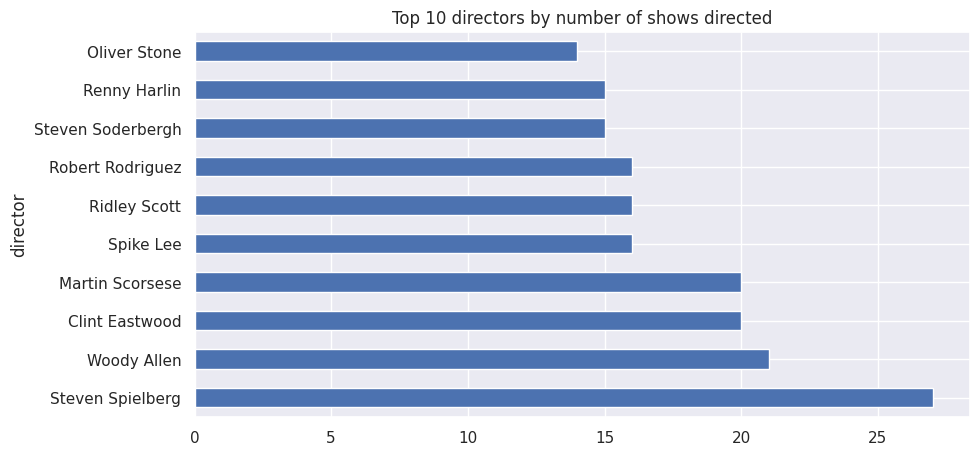

In [ ]:
plt.figure(figsize=(10,5))
df[~(df['director']=='Unknown')].director.value_counts().nlargest(10).plot(kind='barh')
plt.title('Top 10 reżyserów według liczby nakręconych filmów')

Text(0.5, 1.0, ' Top 10 countries with the highest number of shows')

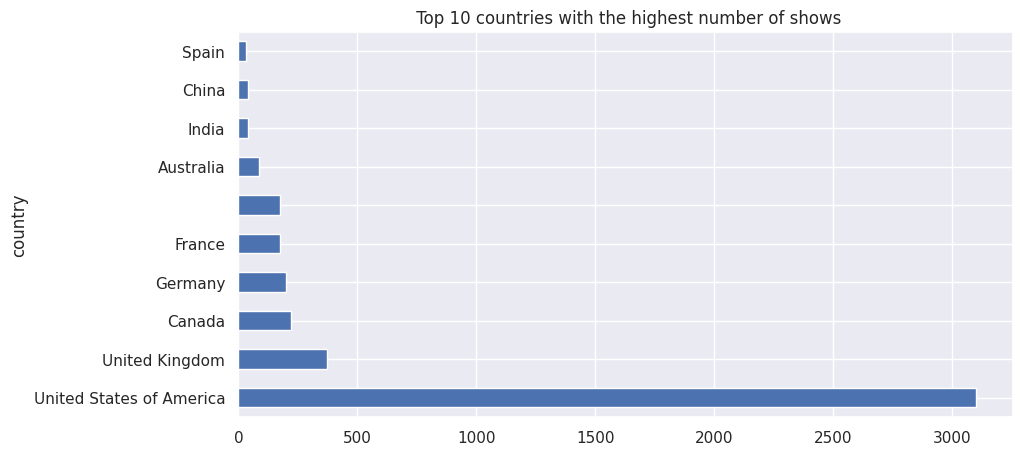

In [ ]:
plt.figure(figsize=(10,5))
df[~(df['country']=='Unknown')].country.value_counts().nlargest(10).plot(kind='barh')
plt.title('Top 10 krajów ze względu na największą liczbę wyprodukowanych filmów')

# Algorytm k-średnich: wydzielenie klastrów ze względu na `keywords`, `overview`, `genres`, `cast` i `director`

In [ ]:
df['content'] = df['keywords'] + " " + df['overview'] + " " + df['genres'] + " " + df['cast'] + " " + df['director']

In [ ]:
# lista ze stopwords
sw = stopwords.words('english')
sw.extend(['one', 'two', 'three', 'new', 'find', 'take', 'must', 'world']) # uzupełniamy o wyrazy "zaśmiecające" klastry

In [ ]:
# funkcja usuwająca stopwords
def remove_stopwords(text):
    text = [word.lower() for word in text.split() if word.lower() not in sw]
    return " ".join(text)

In [ ]:
df['content'] = df['content'].apply(remove_stopwords)
df['content'][20]

"loss father vigilante serum marvel comic scientific experiment peter parker outcast high schooler abandoned parents boy, leaving raised uncle ben aunt may. like teenagers, peter trying figure got person today. peter discovers mysterious briefcase belonged father, begins quest understand parents' disappearance – leading directly oscorp lab dr. curt connors, father's former partner. spider-man set collision course connors' alter ego, lizard, peter make life-altering choices use powers shape destiny become hero. action adventure fantasy andrew garfield emma stone rhys ifans denis leary campbell scott marc webb"

In [ ]:
# funkcja usuwająca interpunkcję
def remove_punctuation(text):
    translator = str.maketrans('', '', string.punctuation)
    return text.translate(translator)

In [ ]:
df['content'] = df['content'].apply(remove_punctuation)
df['content'][20]

'loss father vigilante serum marvel comic scientific experiment peter parker outcast high schooler abandoned parents boy leaving raised uncle ben aunt may like teenagers peter trying figure got person today peter discovers mysterious briefcase belonged father begins quest understand parents disappearance – leading directly oscorp lab dr curt connors fathers former partner spiderman set collision course connors alter ego lizard peter make lifealtering choices use powers shape destiny become hero action adventure fantasy andrew garfield emma stone rhys ifans denis leary campbell scott marc webb'

In [ ]:
tfidf = TfidfVectorizer(stop_words='english', max_features=2000)
tfidf_matrix = tfidf.fit_transform(df['content'])

# redukcja wymiaru (LSA)
svd = TruncatedSVD(n_components=700, random_state=42)
svd_feats = svd.fit_transform(tfidf_matrix)

# k-means
num_clusters = 4
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
df['cluster'] = kmeans.fit_predict(svd_feats)

In [ ]:
# przykłady
print(df[['title', 'cluster']].head(10))

                                          title  cluster
index                                                   
0                                        Avatar        3
1      Pirates of the Caribbean: At World's End        3
2                                       Spectre        2
3                         The Dark Knight Rises        2
4                                   John Carter        3
5                                  Spider-Man 3        3
6                                       Tangled        3
7                       Avengers: Age of Ultron        3
8        Harry Potter and the Half-Blood Prince        3
9            Batman v Superman: Dawn of Justice        3


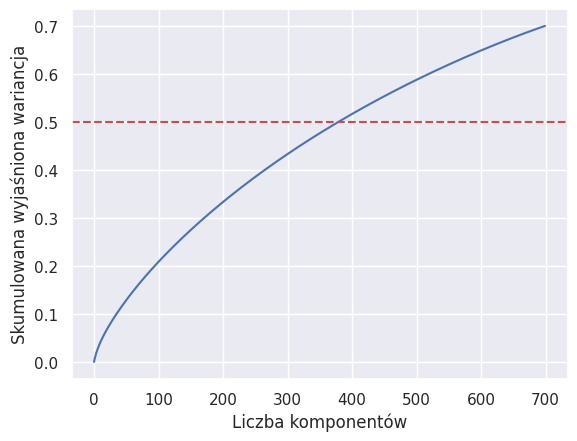

In [ ]:
cum_variance = np.cumsum(svd.explained_variance_ratio_)

plt.plot(cum_variance)
plt.xlabel('Liczba komponentów')
plt.ylabel('Skumulowana wyjaśniona wariancja')
plt.axhline(y=0.5, color='r', linestyle='--')
plt.show()

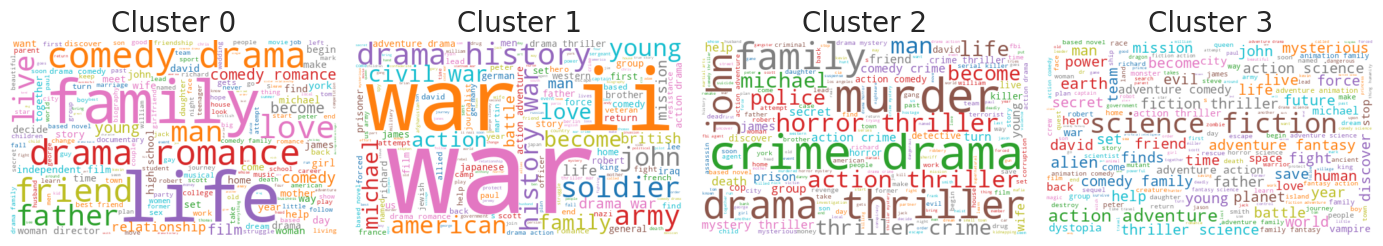

In [ ]:
fig, axes = plt.subplots(1, num_clusters, figsize=(14, 8))
axes = axes.flatten()

for i in range(num_clusters):
    cluster_text = " ".join(df[df['cluster'] == i]['content'])

    wc = WordCloud(width=500, height=300, background_color='white', colormap='tab10').generate(cluster_text)

    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f'Cluster {i}', fontsize=20)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

* Cluster 0: komedie romantyczne, dramaty, filmy o rodzinie, miłości, przyjaciołach
* Cluster 1: filmy wojenne, historyczne
* Cluster 2: kryminały, thrillery, horrory, filmy akcji
* Cluster 3: filmy sci-fi, przygodowe

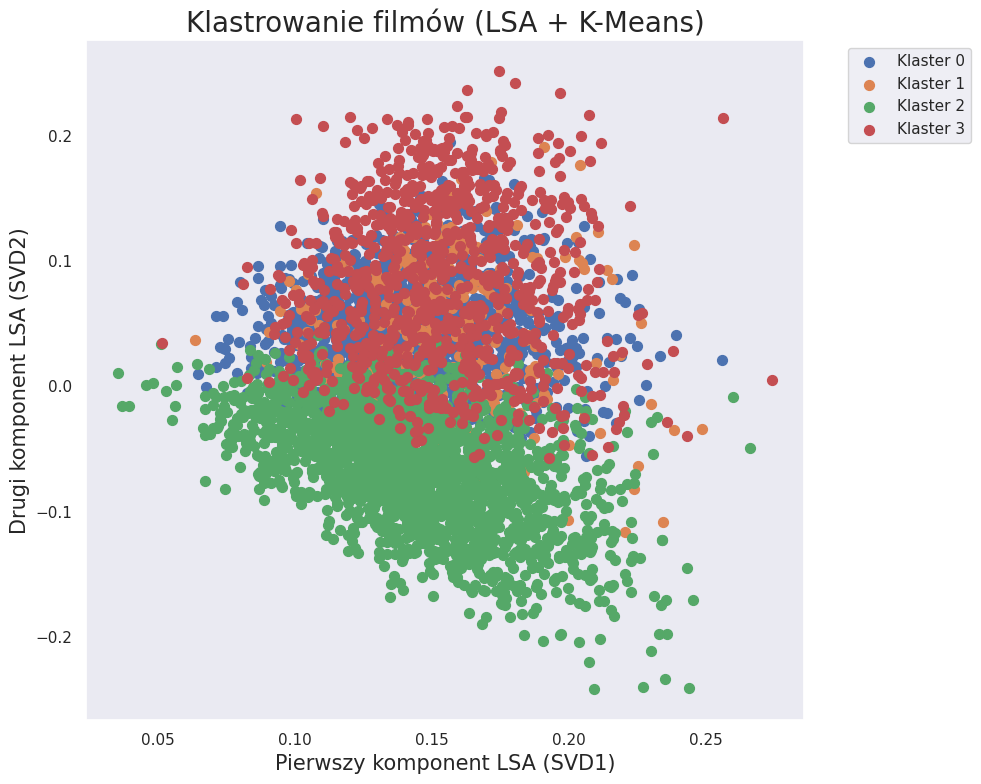

In [ ]:
all_data_df = pd.DataFrame(svd_feats[:, :2], columns=['LSA1', 'LSA2'])

kmeans = KMeans(n_clusters=num_clusters, random_state=0, n_init=10)
kmeans_labels = kmeans.fit_predict(svd_feats)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(1, 1, 1)

ax.set_xlabel('Pierwszy komponent LSA (SVD1)', fontsize=15)
ax.set_ylabel('Drugi komponent LSA (SVD2)', fontsize=15)
ax.set_title('Klastrowanie filmów (LSA + K-Means)', fontsize=20)

targets = range(0, num_clusters)

for target in targets:
    indicesToKeep = (kmeans_labels == target)  # filter data for each cluster

    ax.scatter(all_data_df.loc[indicesToKeep, 'LSA1'],
               all_data_df.loc[indicesToKeep, 'LSA2'],
               s=50, label=f'Klaster {target}')

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid()
plt.tight_layout()
plt.show()